# HW1 Warmup — Stochastic Bandits: setup and two worked examples

**Course:** ID6002W Online and Reinforcement Learning (IIT Madras WSAI web-enabled M.Tech)

**Covers:** The codebase you'll use throughout HW1, plus two worked examples (Hoeffding-based mean estimation, and uniform random as a baseline).

## What this notebook is

This is a **warmup** notebook for HW1. It is not graded. Its purpose is to set up the codebase you'll use in the homework and to walk you through two worked examples end-to-end.

Two worked-out examples are provided, for you to better understand the codebase. You are welcome — and encouraged — to experiment with this code: change the true means, the horizon, the number of seeds, the confidence level; see what the plots do; break things and put them back together. Time spent fiddling here is time saved when you tackle the actual homework.

- **Estimating arm means** with Hoeffding's inequality. Pull each arm many times and visualise how the empirical means and their confidence radii behave as the sample size grows.
- **Uniform random** as a baseline strategy. Define a bandit algorithm, run it for many seeds, and produce three standard views of cumulative regret.

In the actual HW1 notebook, you will then explore three classical bandit algorithms — **ε-greedy**, **Explore-Then-Commit (ETC)**, and **Successive Elimination (SE)** — building on exactly the codebase and plot patterns introduced here.

In [1]:
# === Setup: imports and plotting style ===

import numpy as np                  # numerical arrays + random number generators
import matplotlib.pyplot as plt     # plotting
from functools import partial       # used later to "bind" hyperparameters (e.g. ε) into algorithms

%matplotlib inline

# A few plot defaults so figures look consistent across the notebook.
plt.rcParams["figure.dpi"] = 100    # higher dpi = sharper figures
plt.rcParams["axes.grid"] = True    # show grid by default
plt.rcParams["grid.alpha"] = 0.3    # faded grid lines so they don't dominate

# Fixed starting seed for reproducibility; see the next markdown cell for the why.
BASE_SEED = 20260516

### A note on reproducibility

Bandit experiments are stochastic: rewards are random, and many algorithms also make random choices (e.g. ε-greedy picks a random arm with probability ε). To make results reproducible — same code, same numbers every time — every source of randomness must come from a *Random Number Generator* (RNG) that we seed explicitly.

In numpy, the modern way to do this is `np.random.default_rng(seed)`, which returns a `Generator` object. We create one such generator per experiment run, pass it into the environment, and the environment uses it for all its random draws. Two runs with the same seed produce identical reward sequences.

**Rules of thumb for this homework:**
- Never call `np.random.seed(...)` (this sets global state and is fragile).
- Never call `np.random.rand()` etc. directly (also global state).
- Always create a generator with `np.random.default_rng(seed)` and pass it where it's needed.

**Example usage** (for reference; you don't need to run this):

```python
rng = np.random.default_rng(20260516)   # build a generator from a seed
rng.random()                             # uniform in [0, 1)
rng.integers(0, 5)                       # random integer in {0, 1, 2, 3, 4}
```

Inside this notebook, `run_experiment` (defined below) handles seed management for you: it creates a fresh generator with seed `BASE_SEED + s` for run `s`.

## The provided codebase

The next three cells give you everything you need to *run* bandit experiments — leaving you free to focus on the *algorithms* themselves.

- **`BernoulliBandit`** — the environment. You construct it with a list of true arm means; calling `.pull(arm)` returns a 0/1 reward sampled from that arm's Bernoulli distribution.
- **Plotting helpers** — three functions for the figures you'll produce repeatedly: cumulative regret on a single run, mean cumulative regret averaged across seeds (with a confidence band), and a strip plot showing which arm was pulled at which round.
- **`run_experiment`** — runs an algorithm for `n_seeds` independent seeds and returns the per-seed regret and per-seed arm-pull matrices.

You don't need to modify any of this. Read through it once so you know what's available; then use these pieces as building blocks in the tasks that follow.

In [2]:
# === Provided: BernoulliBandit environment ===

class BernoulliBandit:
    """
    K-arm Bernoulli bandit.

    Parameters
    ----------
    means : sequence of floats in [0, 1]
        True mean reward of each arm.
    rng : np.random.Generator
        Source of randomness owned by this environment instance.

    Attributes
    ----------
    K : int                       Number of arms.
    means : np.ndarray (K,)       True means.
    best_mean : float             max of `means` (used for regret).
    best_arm : int                argmax of `means`.
    pull_counts : np.ndarray (K,) Number of times each arm has been pulled.
    """

    def __init__(self, means, rng):
        # Store true means as a numpy array of floats.
        self.means = np.asarray(means, dtype=float)

        # Sanity check: Bernoulli means must be valid probabilities.
        if np.any((self.means < 0) | (self.means > 1)):
            raise ValueError("Bernoulli means must lie in [0, 1].")

        self.K = len(self.means)               # number of arms
        self.rng = rng                          # this env's own random generator

        # Pre-compute best arm and its mean — used to compute regret.
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))

        # Bookkeeping: how often each arm has been pulled so far.
        # (Algorithms may also track this internally; this is for sanity-checking.)
        self.pull_counts = np.zeros(self.K, dtype=int)

    def pull(self, arm):
        """Pull arm `arm`. Returns a 0/1 reward sampled Bernoulli(means[arm])."""
        self.pull_counts[arm] += 1
        # rng.random() draws uniform in [0, 1); reward = 1 with probability means[arm].
        return int(self.rng.random() < self.means[arm])

    def instantaneous_regret(self, arm):
        """Expected regret incurred by pulling arm `arm`: best_mean − means[arm].

        Note this is the *expected* regret, not the realised one. We use expected
        regret throughout because it's smoother and the standard quantity to plot.
        """
        return self.best_mean - self.means[arm]

In [3]:
# === Provided: plotting helpers ===

def plot_cumulative_regret(regrets, label, ax):
    """Plot cumulative regret for a single run.

    Parameters
    ----------
    regrets : (T,) instantaneous regret per round (not cumulative — we sum here).
    """
    ax.plot(np.cumsum(regrets), label=label)   # cumsum turns per-round regret into cumulative
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret")
    ax.legend()


def plot_averaged_regret(regret_matrix, label, ax, with_band=True):
    """Plot mean cumulative regret across seeds, with optional ±1 std band.

    Parameters
    ----------
    regret_matrix : (n_seeds, T) instantaneous regret per round per seed.
    """
    # Each row is one run; cumsum along time gives (n_seeds, T) cumulative regrets.
    cum = np.cumsum(regret_matrix, axis=1)

    # Aggregate across seeds: mean curve plus standard-deviation band.
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)

    t = np.arange(1, cum.shape[1] + 1)
    line, = ax.plot(t, mean, label=label)
    if with_band:
        # Shaded band shows variability across seeds — wider band = noisier algorithm.
        ax.fill_between(t, mean - std, mean + std, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret  (mean ± 1 std)")
    ax.legend()


def plot_arm_pulls(arm_sequence, ax, K=None):
    """Strip plot: which arm was pulled at which round.

    Useful for visualising the exploration pattern of an algorithm.

    Parameters
    ----------
    arm_sequence : (T,) integer arm indices.
    """
    arm_sequence = np.asarray(arm_sequence)
    t = np.arange(len(arm_sequence))
    ax.scatter(t, arm_sequence, s=6, alpha=0.5)   # small, semi-transparent dots
    ax.set_xlabel("Round t")
    ax.set_ylabel("Arm pulled")
    if K is None:
        K = int(arm_sequence.max()) + 1
    ax.set_yticks(np.arange(K))   # one tick per arm

In [4]:
# === Provided: run_experiment helper ===

def run_experiment(algo_fn, env_factory, T, n_seeds, base_seed=BASE_SEED):
    """Run `algo_fn` for `n_seeds` independent seeds.

    Parameters
    ----------
    algo_fn : callable
        Signature `algo_fn(env, T) -> (arm_sequence, regret_sequence)`.
        Bind any extra params (e.g. ε for ε-greedy) with `functools.partial`
        before passing.
    env_factory : callable
        Signature `env_factory(rng) -> BernoulliBandit`. Builds a fresh env per
        seed — so each seed sees an independent stream of rewards.
    T : int                Horizon.
    n_seeds : int          Number of independent runs to average over.
    base_seed : int        Seeds used are base_seed + 0, base_seed + 1, ...

    Returns
    -------
    regret_matrix : (n_seeds, T) float array of instantaneous regrets.
    arm_matrix    : (n_seeds, T) int   array of arms pulled.
    """
    # Pre-allocate output matrices: one row per seed, one column per round.
    regret_matrix = np.zeros((n_seeds, T))
    arm_matrix = np.zeros((n_seeds, T), dtype=int)

    for s in range(n_seeds):
        # Each run gets its own RNG, derived from base_seed + s.
        # This makes the whole experiment reproducible while keeping runs independent.
        rng = np.random.default_rng(base_seed + s)
        env = env_factory(rng)

        # Run the algorithm. It returns the arms it pulled and the per-round regret.
        arms, regrets = algo_fn(env, T)

        regret_matrix[s] = regrets
        arm_matrix[s] = arms

    return regret_matrix, arm_matrix

---
## Worked example 1 — Estimating arm means with Hoeffding's inequality

Before we run any bandit algorithm, let's understand the *raw material* algorithms work with: empirical means.

**Recall from Lecture 2.** If we pull an arm with unknown mean $\mu \in [0,1]$ for $n$ i.i.d. rounds and form the empirical mean $\hat\mu_n$, **Hoeffding's inequality** (for Bernoulli rewards) says

$$\Pr\!\left(|\hat\mu_n - \mu| \geq \varepsilon\right) \;\leq\; 2 \exp(-2n\varepsilon^2).$$

Fixing a confidence level $\delta \in (0,1)$ and solving $2\exp(-2n\varepsilon^2) \leq \delta$ for $\varepsilon$ gives the **Hoeffding radius**

$$\varepsilon_n(\delta) \;=\; \sqrt{\frac{\log(2/\delta)}{2n}},$$

so with probability at least $1-\delta$, the true mean $\mu$ lies in $[\hat\mu_n - \varepsilon_n(\delta),\; \hat\mu_n + \varepsilon_n(\delta)]$.

The plots below visualise the $1/\sqrt n$ shrinking of this radius on a 5-arm Bernoulli bandit — first as a snapshot at four sample sizes, then as a continuous view tracking the radius over $n$.

In [5]:
# === Worked example 1: collect data for the plots ===

# A 5-arm Bernoulli bandit, with arms 2 and 3 deliberately close together —
# so you'll see how much data is needed to "separate" them.
TRUE_MEANS_DEMO = [0.2, 0.4, 0.5, 0.55, 0.7]
N_MAX = 10000          # pull each arm this many times
DELTA_CONF = 0.05      # confidence level: bands will cover the true mean ≥ 95% of the time

# Build the env. Reuse the same RNG across arms — fine since we pull sequentially.
rng = np.random.default_rng(BASE_SEED)
env = BernoulliBandit(TRUE_MEANS_DEMO, rng)
K = env.K

# Pull each arm N_MAX times. Store every reward so we can compute running means
# at every n along the way.
rewards = np.zeros((K, N_MAX))
for a in range(K):
    for n in range(N_MAX):
        rewards[a, n] = env.pull(a)

# Running empirical mean after n pulls: cumulative sum divided by n.
# Shape: (K, N_MAX) — one row per arm, one column per "after n pulls".
n_array = np.arange(1, N_MAX + 1)
running_means = np.cumsum(rewards, axis=1) / n_array

# Hoeffding radius at every n (same for every arm, since rewards lie in [0, 1]).
# Shape: (N_MAX,).
radii = np.sqrt(np.log(2 / DELTA_CONF) / (2 * n_array))

print(f"Pulled each of the {K} arms {N_MAX} times.")

Pulled each of the 5 arms 10000 times.


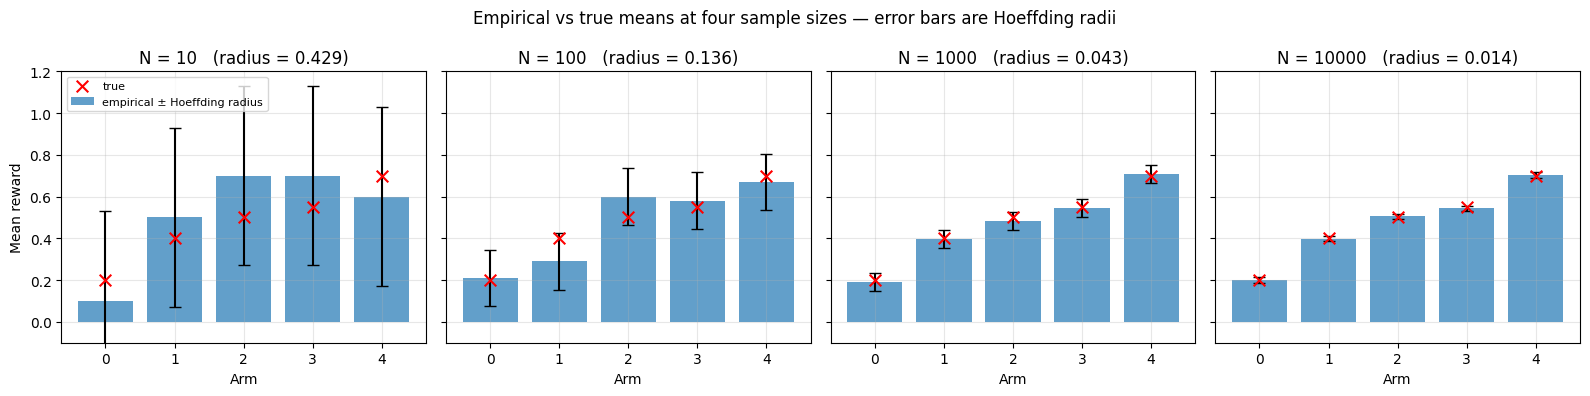

In [6]:
# === Worked example 1: snapshot bar plot with Hoeffding error bars ===
#
# At four chosen values of N, plot the empirical mean for each arm as a bar,
# with error bars of size ± Hoeffding radius. Red x's mark the true means.
# As N grows, bars approach the x's and error bars shrink.

Ns_snapshot = [10, 100, 1000, 10000]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i, N in enumerate(Ns_snapshot):
    ax = axes[i]

    # Empirical means at exactly this N (columns are 0-indexed, so use N-1).
    emp = running_means[:, N - 1]
    radius_at_N = np.sqrt(np.log(2 / DELTA_CONF) / (2 * N))

    arms = np.arange(K)
    ax.bar(arms, emp, yerr=radius_at_N, capsize=4, alpha=0.7,
           label="empirical ± Hoeffding radius")
    ax.scatter(arms, TRUE_MEANS_DEMO, color="red", marker="x", s=70, zorder=5,
               label="true")

    ax.set_title(f"N = {N}   (radius = {radius_at_N:.3f})")
    ax.set_xlabel("Arm")
    ax.set_xticks(arms)
    if i == 0:
        ax.set_ylabel("Mean reward")
        ax.legend(fontsize=8, loc="upper left")
    ax.set_ylim(-0.1, 1.2)

plt.suptitle("Empirical vs true means at four sample sizes — error bars are Hoeffding radii")
plt.tight_layout()
plt.show()

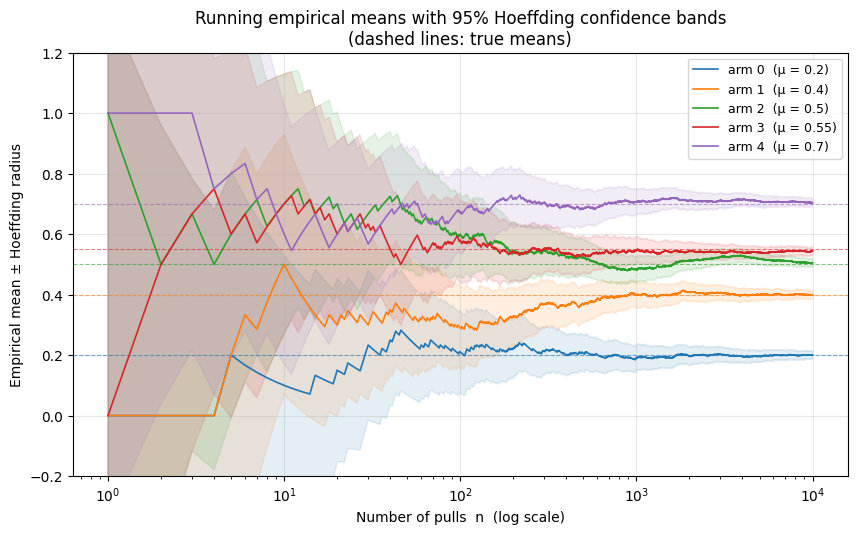

In [7]:
# === Worked example 1: the Hoeffding "sandwich" plot ===
#
# For each arm, show the running empirical mean (solid line) as a function of n,
# with a shaded ±radius band (the "sandwich"). The true mean is shown as a
# horizontal dashed line in the same colour.
#
# Visual story: at small n the bands are wide and overlap; as n grows the bands
# shrink and the arms separate from each other.

fig, ax = plt.subplots(figsize=(10, 5.5))

for a in range(K):
    line, = ax.plot(n_array, running_means[a],
                    label=f"arm {a}  (μ = {TRUE_MEANS_DEMO[a]})",
                    linewidth=1.2)

    # Shaded ±radius band around the running mean — this is the Hoeffding sandwich.
    ax.fill_between(n_array,
                    running_means[a] - radii,
                    running_means[a] + radii,
                    alpha=0.12, color=line.get_color())

    # True mean as a horizontal dashed line in the matching colour.
    ax.axhline(TRUE_MEANS_DEMO[a], linestyle="--", linewidth=0.8,
               color=line.get_color(), alpha=0.6)

ax.set_xscale("log")                 # log scale: see n=10 to n=10000 clearly on one axis
ax.set_xlabel("Number of pulls  n  (log scale)")
ax.set_ylabel("Empirical mean ± Hoeffding radius")
ax.set_title(f"Running empirical means with {int((1 - DELTA_CONF) * 100)}% Hoeffding confidence bands\n"
             f"(dashed lines: true means)")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(-0.2, 1.2)
plt.show()

### What to take away

- At **N = 10**, the radius is large (~0.43) — the confidence bands of all five arms overlap heavily, and the empirical ranking need not match the true ranking.
- At **N = 100**, the radius drops to ~0.14. Arm 4 (μ = 0.7) sits clearly above the rest, but arms 2 (μ = 0.5) and 3 (μ = 0.55) still overlap.
- At **N = 10000**, the radius is ~0.014 — all five arms are clearly separated.

Different arms need different amounts of data to be distinguished from one another, and arms whose means are close together need many more samples than arms whose means are far apart. Keep this in mind as we look at algorithms.

---
## Worked example 2 — Uniform random as a baseline

The simplest possible bandit strategy: at every round, pick an arm uniformly at random. No learning, no preference.

This example exists mainly to show *how to write a bandit algorithm and plot its regret* end-to-end, using the building blocks defined above. The same code patterns will reappear in the tasks, so it's worth reading carefully — and copying — when you get there.

We'll generate three views of regret:

1. **Single-run cumulative regret** — what one realisation of the algorithm does.
2. **Many trajectories overlaid** — 50 individual cumulative-regret curves on one axis.
3. **Averaged cumulative regret with ±1 std band** — the typical behaviour summarised across 50 seeds.

Setting: the same 5-arm Bernoulli bandit as before, with true means `[0.2, 0.4, 0.5, 0.55, 0.7]`. Horizon `T = 1000`.

### A note on what "regret" means here

The true (random) regret incurred by pulling arm $A_t$ at round $t$ is $\mu^* - X_t$, where $X_t$ is the realised reward. We will not plot this — it is too noisy, and most of the literature works with its expectation conditional on the arm pulled:

$$r_t \;=\; \mu^* - \mu_{A_t},$$

which is called the **pseudo-regret** at round $t$. This is what `env.instantaneous_regret(a)` returns, and what every "regret" plot in this notebook actually shows. The distinction between regret and pseudo-regret is formalised in Lecture 3; for now, just know that throughout this homework, "regret" means pseudo-regret.

In [8]:
# === Worked example 2: algorithm and env factory ===

def uniform_random(env, T):
    """Pull a uniformly random arm at every round.

    Returns
    -------
    arm_sequence    : (T,) int     arm pulled at each round.
    regret_sequence : (T,) float   instantaneous (expected) regret per round.
    """
    K = env.K
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    for t in range(T):
        a = int(env.rng.integers(K))                       # uniform draw from {0, ..., K-1}
        env.pull(a)                                         # reward unused; keeps pull_counts honest
        arm_sequence[t] = a
        regret_sequence[t] = env.instantaneous_regret(a)    # expected regret of pulling a

    return arm_sequence, regret_sequence


def env_factory_5arm(rng):
    """Builds the 5-arm Bernoulli env used in the worked examples and Task 1."""
    return BernoulliBandit([0.2, 0.4, 0.5, 0.55, 0.7], rng)

In [9]:
# === Worked example 2: run the experiments ===

T = 1000
n_seeds = 50

# One representative single run, used by Plot 1.
rng_single = np.random.default_rng(BASE_SEED)
env_single = env_factory_5arm(rng_single)
arms_single, regrets_single = uniform_random(env_single, T)

# Many runs over independent seeds, used by Plots 2 and 3.
regret_matrix, _ = run_experiment(uniform_random, env_factory_5arm, T, n_seeds)
cum_matrix = np.cumsum(regret_matrix, axis=1)   # (n_seeds, T) cumulative regrets

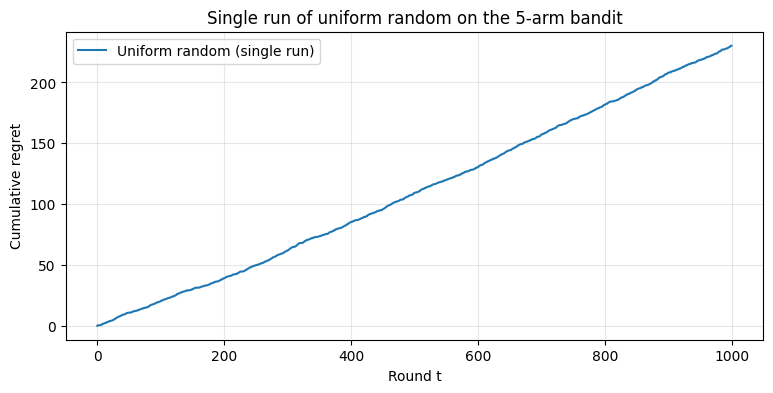

In [10]:
# === Plot 1: single-run cumulative regret ===

fig, ax = plt.subplots(figsize=(9, 4))
plot_cumulative_regret(regrets_single, "Uniform random (single run)", ax)
ax.set_title("Single run of uniform random on the 5-arm bandit")
plt.show()

**Plot 2: many trajectories overlaid.** Useful pattern: when individual runs have qualitatively different behaviour (e.g. for ETC, some commit to the right arm and some commit wrong), this view reveals a spread that an averaged plot would hide. For uniform random it's not very dramatic — the trajectories all look similar — but the code pattern is worth knowing.

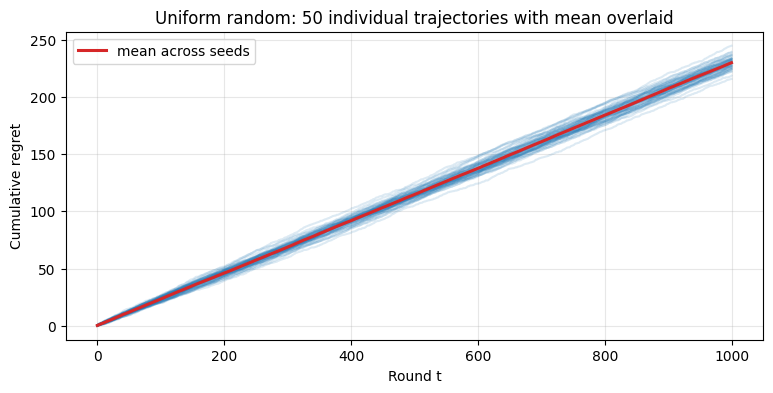

In [11]:
# === Plot 2: many trajectories overlaid, with the mean in bold ===

fig, ax = plt.subplots(figsize=(9, 4))
for s in range(n_seeds):
    ax.plot(cum_matrix[s], color="C0", alpha=0.15)             # one faded line per seed
ax.plot(cum_matrix.mean(axis=0), color="C3", linewidth=2.2,
        label="mean across seeds")                              # bold mean
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret")
ax.set_title(f"Uniform random: {n_seeds} individual trajectories with mean overlaid")
ax.legend()
plt.show()

**Plot 3: averaged regret with a ±1 std band.** Same data as Plot 2, summarised differently: the mean curve plus a shaded ±1 std band. This is the workhorse plot for comparing algorithms in the tasks below.

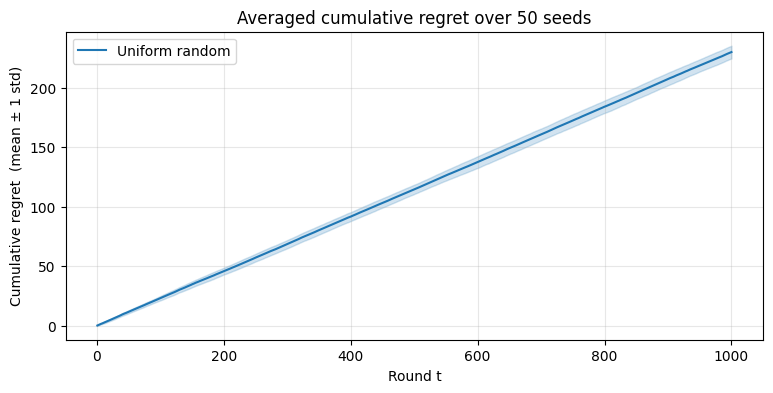

In [12]:
# === Plot 3: averaged cumulative regret with ±1 std band ===

fig, ax = plt.subplots(figsize=(9, 4))
plot_averaged_regret(regret_matrix, "Uniform random", ax)
ax.set_title(f"Averaged cumulative regret over {n_seeds} seeds")
plt.show()

### What to take away

For uniform random, all three plots tell the same simple story: cumulative regret grows linearly, with very little run-to-run variation. There's nothing interesting going on here — the algorithm makes no use of the rewards it sees, so its behaviour is the same on every run up to noise.

The point of the example was the code pattern: each plot was produced with a few lines using `uniform_random`, `run_experiment`, and the plotting helpers. The tasks below will reuse exactly these patterns with smarter algorithms, where each view starts to show something genuinely different.

---
## What's next

You now have everything you need for HW1:

- A working `BernoulliBandit` environment.
- Plotting helpers for cumulative regret in three views.
- A `run_experiment` helper that handles seeds and sweeps for you.
- Two worked examples showing how these pieces fit together.

The HW1 notebook (released separately) will use this same codebase to study **ε-greedy**, **Explore-Then-Commit**, and **Successive Elimination**.